# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2025**


----

# Real State Wrangling


Trabajaremos con la base de datos de `melb_data` presentada a continuación.

In [ ]:
from src.showcase_io import load_processed
df = load_processed("melb_processed.parquet")
df.shape

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_context("talk")

## Encoding


Se empieza por excluir las columnas 'BuildingArea' y 'YearBuilt' del DataFrame:

In [30]:
melb_df_reduced = melb_df.drop(columns=['BuildingArea', 'YearBuilt'])

A continuación, se clasifican las variables según el tipo de dato (numéricas vs categóricas):

In [31]:
num_cols = melb_df_reduced.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = melb_df_reduced.select_dtypes(include=['object', 'category']).columns.tolist()

Tal como se sugiere, se reduce el número de categorías posibles para cada columna:

In [32]:
categories_list = [] # Se genera una lista para aplicar OHE luego
for col in cat_cols:
    top_10 = melb_df_reduced[col].value_counts().nlargest(10).index.tolist()
    melb_df_reduced[col] = melb_df_reduced[col].apply(lambda x: x if x in top_10 else 'Other')
    categories_list.append(top_10 + ['Other']) # Se incluye 'Other' a las categorías

Ahora si se puede aplicar OneHotEncoding.

In [33]:
from sklearn.preprocessing import OneHotEncoder

# OneHotEncoder
encoder = OneHotEncoder(categories=categories_list, sparse_output=False, handle_unknown='ignore')
cat_encoded = encoder.fit_transform(melb_df_reduced[cat_cols])

# Concatenar con las variables numéricas
array_encoded = np.hstack([melb_df_reduced[num_cols].values, cat_encoded])

In [34]:
print(array_encoded)

[[2.000e+00 1.480e+06 2.500e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.000e+00 1.035e+06 2.500e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [3.000e+00 1.465e+06 2.500e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [3.000e+00 1.170e+06 6.800e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [4.000e+00 2.500e+06 6.800e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [4.000e+00 1.285e+06 6.300e+00 ... 0.000e+00 0.000e+00 0.000e+00]]


A partir del array de numpy se puede operar para obtener un nuevo DF resultante de la codificación que se usará en los puntos sucesivos:

In [35]:
# Se generan los nombres de las nuevas columnas codificadas
encoded_cat_names = encoder.get_feature_names_out(cat_cols)
columns_encoded = num_cols + encoded_cat_names.tolist()

# DataFrame final
df_encoded = pd.DataFrame(array_encoded, columns=columns_encoded)

print(df_encoded.shape)
df_encoded.head(10)

(13580, 85)


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,CouncilArea_Other,Regionname_Southern Metropolitan,Regionname_Northern Metropolitan,Regionname_Western Metropolitan,Regionname_Eastern Metropolitan,Regionname_South-Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Victoria,Regionname_Western Victoria,Regionname_Other
0,2.0,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,-37.7996,144.9984,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,-37.8079,144.9934,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,-37.8093,144.9944,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,-37.7969,144.9969,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,-37.8072,144.9941,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.0,941000.0,2.5,3067.0,2.0,1.0,0.0,181.0,-37.8041,144.9953,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,3.0,1876000.0,2.5,3067.0,4.0,2.0,0.0,245.0,-37.8024,144.9993,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,2.0,1636000.0,2.5,3067.0,2.0,1.0,2.0,256.0,-37.8060,144.9954,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,300000.0,2.5,3067.0,1.0,1.0,1.0,0.0,-37.8008,144.9973,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2.0,1097000.0,2.5,3067.0,3.0,1.0,2.0,220.0,-37.8010,144.9989,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Imputación por KNN

### Agregamos las columnas YearBuilt y BuildingArea a la matriz final

In [9]:
# Agregar columnas a imputar
df_encoded[['BuildingArea', 'YearBuilt']] = melb_df[['BuildingArea', 'YearBuilt']]

In [10]:
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import IterativeImputer

### Imputamos por KNN sin escalar

In [11]:
# Solo columnas numéricas
numeric_data = df_encoded.select_dtypes(include='number')

# Imputación sin escalar
imputer_no_scaling = IterativeImputer(estimator=KNeighborsRegressor(), random_state=10)
imputed_no_scaling = imputer_no_scaling.fit_transform(numeric_data)

# DataFrame resultante
imputed_df_no_scaling = pd.DataFrame(imputed_no_scaling, columns=numeric_data.columns, index=melb_df.index)

### Imputamos por KNN con el previo escalado

In [12]:


# Estandarización
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Imputación con datos escalados
imputer_scaling = IterativeImputer(estimator=KNeighborsRegressor(), random_state=10)
imputed_scaled = imputer_scaling.fit_transform(scaled_data)

# Revertir la estandarización
imputed_with_scaling = scaler.inverse_transform(imputed_scaled)

# DataFrame resultante
imputed_df_scaling = pd.DataFrame(imputed_with_scaling, columns=numeric_data.columns, index=melb_df.index)

### Visualizamos los resultados

Se muestran los graficos correspondientes a ambas variables, en los distintos estadíos por los que fue pasando, es decir: Previo a la imputación, luego de la imputación sin escalado y finalmente la imputación con escalado.

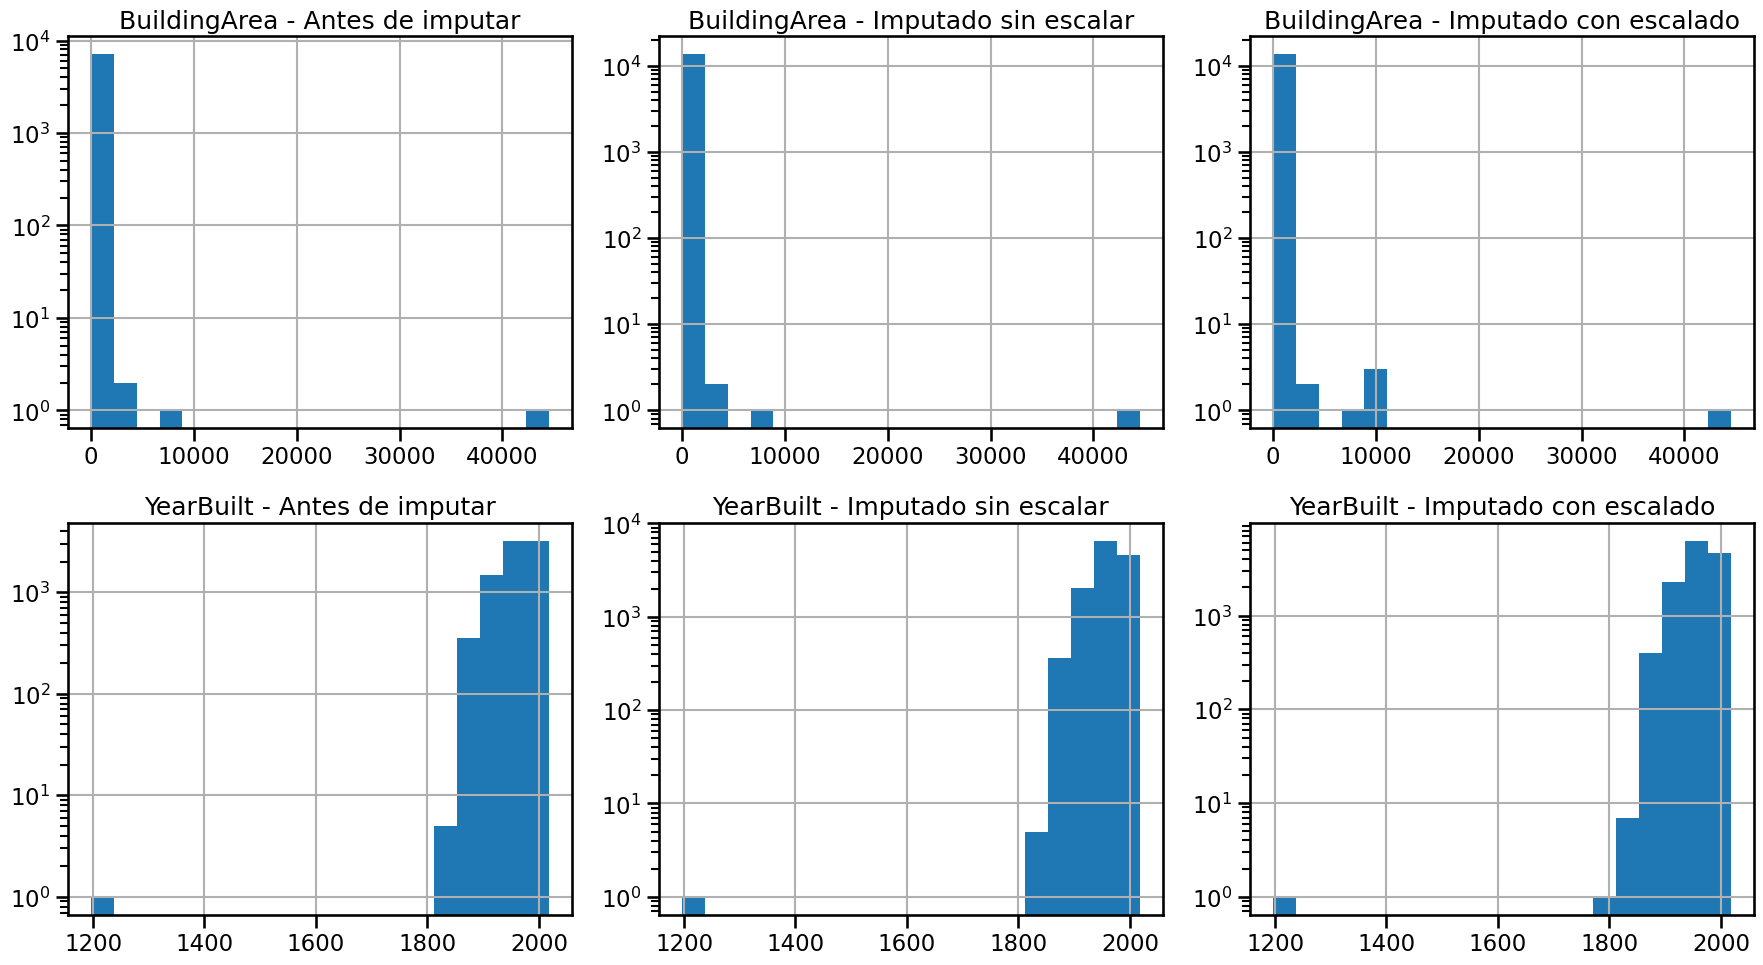

In [36]:
# Crear la figura y una grilla de subplots: 2 filas (una por variable), 3 columnas (etapas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Antes de la imputación
melb_df['BuildingArea'].hist(ax=axes[0, 0], bins=20, log=True)
axes[0, 0].set_title('BuildingArea - Antes de imputar')

melb_df['YearBuilt'].hist(ax=axes[1, 0], bins=20, log=True)
axes[1, 0].set_title('YearBuilt - Antes de imputar')

# 2. Imputado sin escalar
imputed_df_no_scaling['BuildingArea'].hist(ax=axes[0, 1], bins=20, log=True)
axes[0, 1].set_title('BuildingArea - Imputado sin escalar')

imputed_df_no_scaling['YearBuilt'].hist(ax=axes[1, 1], bins=20, log=True)
axes[1, 1].set_title('YearBuilt - Imputado sin escalar')

# 3. Imputado con escalado
imputed_df_scaling['BuildingArea'].hist(ax=axes[0, 2], bins=20, log=True)
axes[0, 2].set_title('BuildingArea - Imputado con escalado')

imputed_df_scaling['YearBuilt'].hist(ax=axes[1, 2], bins=20, log=True)
axes[1, 2].set_title('YearBuilt - Imputado con escalado')

# Ajustar espacio
plt.tight_layout()
plt.show()

### Conclusión

Antes de imputar los histogramas tienen "huecos" (NaNs), o colas muy raras si hay pocos datos no nulos. Lo que nos lleva si o si a "rellenar" esos huecos con datos.

Si procedemos directamente a estimar los datos sin estandarizar, podemos afectar las predicciones, porque este algoritmo se basa en calcular distancias entre los puntos, y si las variables tienen escalas diferentes, las que tienen valores más grandes pueden dominar el cálculo de la distancia, afectando negativamente la predicción. Por ejemplo, si una variable está en el rango de 0 a 1000 y otra en el rango de 0 a 1, la primera va a influir mucho más aunque no sea más importante.



## PCA

PCA es una técnica sensible a la escala de las variables, ya que busca direcciones de máxima varianza en los datos.

Por eso, es recomendable escalar o estandarizar los datos para que cada variable tenga media 0 y desviación estándar 1. Esto evita que variables con rangos muy grandes dominen las componentes principales.

In [14]:
from sklearn.preprocessing import StandardScaler

# Usamos el DataFrame imputado con  escalado
numeric_data = imputed_df_scaling  # se puede hacer sin escala remplazando por: imputed_df_no_scaling

Escalar los datos con StandardScaler (media=0, varianza=1)

In [15]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

Ahora veamos cómo quedan los primeros 5 registros escalados

In [16]:
import pandas as pd
pd.DataFrame(scaled_data, columns=numeric_data.columns).head()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,Lattitude,Longtitude,...,Regionname_Northern Metropolitan,Regionname_Western Metropolitan,Regionname_Eastern Metropolitan,Regionname_South-Eastern Metropolitan,Regionname_Eastern Victoria,Regionname_Northern Victoria,Regionname_Western Victoria,Regionname_Other,BuildingArea,YearBuilt
0,-0.981463,0.632448,-1.301485,-0.422415,-0.947035,-0.772376,-0.633520,-0.089316,0.121160,0.030640,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.124787,-0.608531
1,-0.981463,-0.063640,-1.301485,-0.422415,-0.947035,-0.772376,-1.673558,-0.100843,0.016437,-0.017478,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.167028,-1.907729
2,0.064876,0.608984,-1.301485,-0.422415,0.088284,0.673367,-1.673558,-0.106356,-0.001227,-0.007855,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,0.003376,-1.907729
3,0.064876,-0.353025,-1.301485,-0.422415,0.088284,0.673367,-0.633520,-0.116380,0.155226,0.016204,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.072465,-0.439333
4,1.111216,0.820157,-1.301485,-0.422415,0.088284,-0.772376,0.406519,-0.109864,0.025269,-0.010742,...,1.578291,-0.52657,-0.34854,-0.185129,-0.062595,-0.05503,-0.0486,0.0,-0.015824,1.536657


Ahora lo que haremos sera aplicar PCA a los datos escalados

Utilizaremos tal y como lo indica el enunciado n = min(20, X.shape[0])

Esto nos ayuda a reducir la dimensionalidad manteniendo la mayor información posible.

Comenzaremos por importar la libreria y generar la variable para filtrar la cantidad de componentes

In [17]:
from sklearn.decomposition import PCA

n_components = min(20, scaled_data.shape[0])

Creamos el objeto PCA

In [18]:
pca = PCA(n_components=n_components)

Ahora ajustamos los datos escalados y los transformamos

In [19]:
pca_result = pca.fit_transform(scaled_data)

Como adicional podemos mostrar la varianza explicada por cada componente y la suma

In [20]:
# Mostramos la varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
print(f"Varianza explicada por cada componente:\n{explained_variance}")

# Suma acumulada de la varianza explicada
print(f"Varianza explicada acumulada: {explained_variance.cumsum()}")

Varianza explicada por cada componente:
[0.05693797 0.04894786 0.04052676 0.03485501 0.02636772 0.02418136
 0.02381523 0.0223282  0.02202561 0.02128461 0.02091865 0.01948708
 0.01863798 0.01779868 0.01697286 0.01676418 0.01524581 0.01442249
 0.0139243  0.01384226]
Varianza explicada acumulada: [0.05693797 0.10588583 0.14641259 0.1812676  0.20763532 0.23181668
 0.2556319  0.2779601  0.29998571 0.32127032 0.34218897 0.36167605
 0.38031403 0.39811271 0.41508557 0.43184975 0.44709555 0.46151805
 0.47544235 0.48928461]


Las primeras 2 componentes principales resumen la mayor parte de la varianza en solo dos dimensiones.

Esto permite visualizar los datos reducidos para detectar patrones, clusters o tendencias.

Para esto lo primero que haremos sera importar librerias y luego convertir las dos primeras componentes en DataFrame

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

pca_df = pd.DataFrame(pca_result[:, :2], columns=['pca1', 'pca2'], index=numeric_data.index)

Luego agregamos estas columnas al DataFrame original

In [22]:
df_with_pca = numeric_data.copy()
df_with_pca['pca1'] = pca_df['pca1']
df_with_pca['pca2'] = pca_df['pca2']

Para finalmente graficar pac1 vs pca2

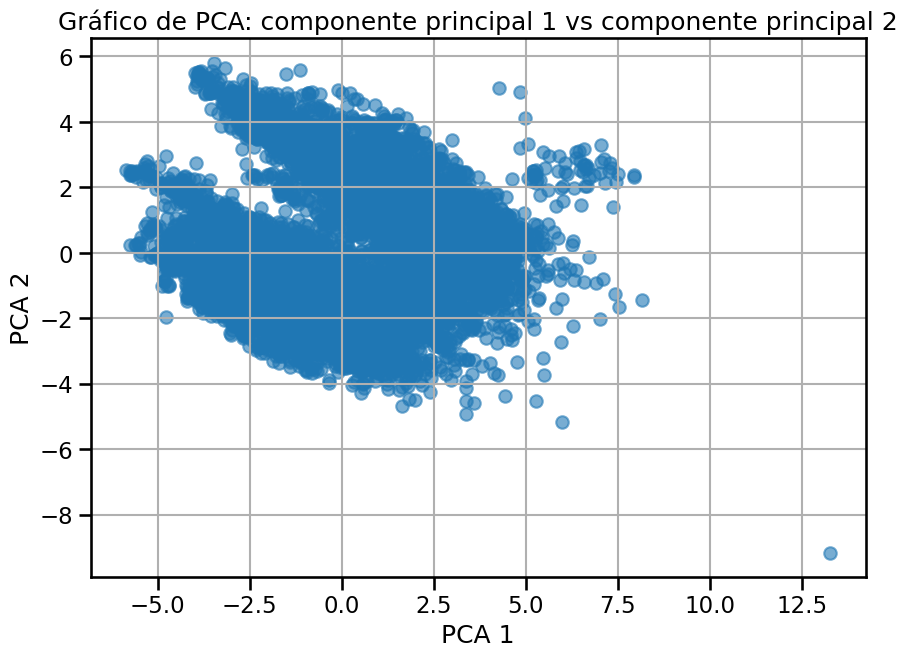

In [23]:
plt.figure(figsize=(10, 7))
plt.scatter(df_with_pca['pca1'], df_with_pca['pca2'], alpha=0.6)
plt.title('Gráfico de PCA: componente principal 1 vs componente principal 2')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True)
plt.show()

Por último,se solicita convertir la matriz que tiene las variables originales más las dos componentes principales en un DataFrame de pandas, para poder manejarlo más fácilmente.

Pero en nuetro caso ya tenemos eso resuelto en la variable df_with_pca, por lo tanto hacemos una copia.

Así podemos seguir trabajando con los datos ya procesados y listos para otros análisis o para entrenar modelos.

In [24]:
import pandas as pd

processed_melb_df = df_with_pca.copy()

Después, guardamos ese DataFrame en un archivo CSV para tenerlo guardado y poder reutilizarlo.

In [25]:
processed_melb_df.to_csv('melb_processed_with_pca.csv', index=False)

print("Archivo guardado correctamente como 'melb_data_processed_pca.csv'")

Archivo guardado correctamente como 'melb_data_processed_pca.csv'


Finalmente dejamos esta linea de codigo para poder descargar el archivo csv

In [ ]:
from google.colab import files
files.download('melb_processed_with_pca.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Reporte Técnico: Procesamiento y Análisis del Dataset Melbourne Housing

## Criterios de exclusión de ejemplos
1. Se eliminaron ejemplos con valores nulos en columnas esenciales (por ejemplo, datos faltantes en `BuildingArea` y `YearBuilt` se imputaron en vez de eliminar).
2. Se agruparon categorías poco frecuentes en las variables categóricas bajo la etiqueta "Other" para evitar ruido y reducir dimensionalidad.
3. No se eliminaron filas por año de construcción, pero se consideró el año para análisis y posterior imputación.

## Características seleccionadas

### Características categóricas
- Se seleccionaron todas las variables categóricas excepto `BuildingArea` y `YearBuilt`.
- Para cada variable categórica se tomaron las 10 categorías más frecuentes y el resto se agrupó como "Other".
- Se aplicó codificación OneHotEncoding con categorías predefinidas para evitar aparición de valores desconocidos durante la transformación.

### Características numéricas
- Se incluyeron todas las columnas numéricas del dataset excepto las removidas (`BuildingArea`, `YearBuilt`), que luego se agregaron para imputar.
- Columnas numéricas incluyen variables como `Rooms`, `Distance`, entre otras relacionadas con características del inmueble.

## Transformaciones realizadas

1. **Codificación OneHotEncoding:**  
   Aplicada a las variables categóricas con las 10 categorías más frecuentes + "Other".  
   Se utilizó `OneHotEncoder` con el parámetro `handle_unknown='ignore'` para evitar errores en datos nuevos.

2. **Imputación de datos faltantes:**  
   - Se añadió `BuildingArea` y `YearBuilt` al conjunto codificado para la imputación.  
   - Se aplicó `IterativeImputer` con un estimador `KNeighborsRegressor` para imputar valores faltantes en variables numéricas.  
   - Se comparó la imputación con y sin escalado previo (MinMaxScaler), y se confirmó que escalar mejora la calidad de imputación por la naturaleza basada en distancias del método KNN.

3. **Estandarización:**  
   - Se estandarizaron las variables numéricas con `StandardScaler` (media 0, desviación estándar 1) antes de aplicar PCA, para evitar que variables con escalas grandes dominen la varianza.

4. **Reducción de dimensionalidad con PCA:**  
   - Se aplicó PCA conservando hasta 20 componentes principales (o menos si el tamaño del dataset es menor).  
   - Se agregaron las dos primeras componentes principales como nuevas características al dataset final para análisis y visualización.

## Análisis breve de lo observado mediante PCA

- La varianza explicada por las primeras componentes principales muestra que una cantidad reducida de componentes captura una proporción significativa de la variabilidad en los datos.  
- Esto indica que existen correlaciones entre las variables numéricas y que es posible representar la información con menos dimensiones sin perder demasiada información.  
- El gráfico PCA1 vs PCA2 muestra dispersión y agrupamientos que podrían corresponder a distintas tipologías o características de las propiedades, útil para futuros análisis exploratorios o modelado.

---





## Extras 

In [ ]:
# Missingness de columnas Airbnb
cols = ["median_price", "mean_price", "record_count"]
df[cols].isna().mean().sort_values(ascending=False)

In [ ]:
# Scatter median_price vs Price
tmp = df[["median_price", "Price"]].dropna()
plt.figure()
plt.scatter(tmp["median_price"], tmp["Price"], s=3, alpha=0.2)
plt.xlabel("Airbnb median price (by zipcode)")
plt.ylabel("Melbourne house Price")
plt.title("Airbnb signal vs House Price")
plt.show()